# Capstone Two: Modeling
## Class A/B/C Multifamily Risk Score in USA
**Author:** Daksha Gummadi

This notebook builds machine learning models to predict year over year rent growth for multifamily properties across the USA. Model goal is to predict rent_growth_yoy using market indicators. The response variable is rent_growth_yoy continuous > this is a regression problem.

## Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load and Prepare Data](#2-load-and-prepare-data)
3. [Train & Test Split](#3-trainttest-split)
4. [Model 1: Linear Regression (Baseline)](#4-model-1-linear-regression-baseline)
5. [Model 2: Decision Tree Regressor](#5-model-2-decision-tree-regressor)
6. [Model 3: Random Forest Regressor with Hyperparameter Tuning](#6-model-3-random-forest-regressor-with-hyperparameter-tuning)
7. [Model Comparison and Final Selection](#7-model-comparison-and-final-selection)
8. [Conclusion](#8-conclusion)

## 1. Import Libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 2. Load and Prepare Data
I load the cleaned dataset that was saved in the Data Wrangling step. I also create three new columns that look back one month at the vacancy rate, building permits, and rent growth. These are called lag features because they use last month's numbers to help predict this month's rent growth.

In [57]:
df = pd.read_csv('master_dataset_cleaned.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (72, 14)


,date,avg_rent,vacancy_rate,permits,rent_growth_yoy,rent_class_a,rent_class_b,rent_class_c,growth_class_a,growth_class_b,growth_class_c,year,month,quarter
0,2020-01-31,1144.559911,6.600000,1495.0,NaN,1652.213252,1076.384644,773.257105,NaN,NaN,NaN,2020,1,1
1,2020-02-29,1150.840542,6.300000,1455.0,NaN,1660.939300,1083.146596,776.129677,NaN,NaN,NaN,2020,2,1
2,2020-03-31,1157.791469,6.000000,1346.0,NaN,1666.230657,1091.209584,782.516050,NaN,NaN,NaN,2020,3,1
3,2020-04-30,1155.929327,5.700000,1076.0,NaN,1653.767831,1090.998773,784.205937,NaN,NaN,NaN,2020,4,2
4,2020-05-31,1154.101083,5.933333,1250.0,NaN,1643.310542,1091.453494,786.572517,NaN,NaN,NaN,2020,5,2


In [123]:
df['vacancy_lag_1'] = df['vacancy_rate'].shift(1)
df['permits_lag_1'] = df['permits'].shift(1)
df['growth_lag_1']  = df['rent_growth_yoy'].shift(1)
features = ['vacancy_rate', 'permits', 'vacancy_lag_1', 'permits_lag_1', 'growth_lag_1']
target   = 'rent_growth_yoy'
model_df = df[features + [target, 'date']].dropna().reset_index(drop=True)
print(f"Modeling dataset shape: {model_df.shape}")
model_df.head()

Modeling dataset shape: (57, 7)


,vacancy_rate,permits,vacancy_lag_1,permits_lag_1,growth_lag_1,rent_growth_yoy,date
0,6.600000,1711.0,6.800000,1855.0,1.810765,1.405588,2021-02-28
1,6.400000,1756.0,6.600000,1711.0,1.405588,1.335449,2021-03-31
2,6.200000,1721.0,6.400000,1756.0,1.335449,2.720338,2021-04-30
3,6.066667,1703.0,6.200000,1721.0,2.720338,4.200468,2021-05-31
4,5.933333,1654.0,6.066667,1703.0,4.200468,6.282589,2021-06-30


## 3. Train/Test Split

Because my data is organized by month in order from 2020 to 2025, I split it by time. The earlier months are used for training and the more recent months are used for testing. I do not split randomly because that would let the model peek at future data when learning, which would make it look better than it really is. I use the first 80% of months for training and the last 20% for testing.

In [62]:
split_idx = int(len(model_df) * 0.80)

train = model_df.iloc[:split_idx]
test  = model_df.iloc[split_idx:]

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print(f"Training set: {X_train.shape[0]} rows  ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Testing set:  {X_test.shape[0]} rows  ({test['date'].min().date()} to {test['date'].max().date()})")

Training set: 45 rows  (2021-02-28 to 2024-10-31)
Testing set:  12 rows  (2024-11-30 to 2025-10-31)


In [64]:
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

I create a helper function that trains each model and prints four scores so I can compare them all the same way.

In [67]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    """Fit model, print train and test metrics, return test metrics dict."""
    model.fit(X_tr, y_tr)

    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    metrics = {
        'Model'    : name,
        'MAE'      : mean_absolute_error(y_te, y_pred_test),
        'RMSE'     : mean_squared_error(y_te, y_pred_test, squared=False),
        'R2'       : r2_score(y_te, y_pred_test),
        'R2_train' : r2_score(y_tr, y_pred_train)
    }

    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Train R²  : {metrics['R2_train']:.4f}")
    print(f"  Test  R²  : {metrics['R2']:.4f}")
    print(f"  Test  MAE : {metrics['MAE']:.4f}")
    print(f"  Test  RMSE: {metrics['RMSE']:.4f}")

    return metrics, y_pred_test

## 4. Model 1: Linear Regression 
Linear Regression is the simplest model I can build. It draws a straight line through the data to make predictions. I use it as a starting point to compare against more complex models. Since it has no settings to tune, I use 5-fold cross-validation which splits the training data into 5 chunks and tests the model 5 times to get a reliable average score.

In [70]:
lr = LinearRegression()

# 5-fold cross-validation on training set
cv_scores = cross_val_score(lr, X_train_sc, y_train, cv=5, scoring='r2')
print(f"Linear Regression — CV R² scores: {cv_scores.round(3)}")
print(f"Mean CV R²: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

m1_metrics, m1_preds = evaluate(
    'Linear Regression', lr, X_train_sc, y_train, X_test_sc, y_test
)

Linear Regression — CV R² scores: [ 0.725 -1.321 -0.525  0.281 -7.876]
Mean CV R²: -1.7433  |  Std: 3.1451

  Linear Regression
  Train R²  : 0.9539
  Test  R²  : 0.6509
  Test  MAE : 0.2896
  Test  RMSE: 0.3943


## 5. Model 2: Decision Tree Regressor

A Decision Tree works by asking a series of yes or no questions about the data to make a prediction. It can pick up on patterns that are not straight lines. I use GridSearchCV to automatically test different settings and find the best combination. It tries different values for how deep the tree can grow and how many data points it needs before making a split. It tests all combinations using 5-fold cross-validation and picks the best one.

In [73]:
dt_params = {
    'max_depth'        : [2, 3, 4, 5],
    'min_samples_split': [2, 4, 6]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring='r2',
    refit=True
)
dt_grid.fit(X_train_sc, y_train)

print(f"Best Decision Tree params: {dt_grid.best_params_}")
print(f"Best CV R²: {dt_grid.best_score_:.4f}")

m2_metrics, m2_preds = evaluate(
    'Decision Tree (Tuned)', dt_grid.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

Best Decision Tree params: {'max_depth': 4, 'min_samples_split': 2}
Best CV R²: -0.9720

  Decision Tree (Tuned)
  Train R²  : 0.9913
  Test  R²  : -0.6224
  Test  MAE : 0.6236
  Test  RMSE: 0.8500


## 6. Model 3: Random Forest Regressor with Hyperparameter Tuning

A Random Forest builds hundreds of decision trees and averages all their predictions together. Because it combines many trees instead of relying on just one, it tends to be more accurate and less likely to memorize the training data. I again use GridSearchCV with 5-fold cross-validation to find the best number of trees and how deep each tree should grow.

In [76]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [2, 3, 4, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring='r2',
    refit=True
)
rf_grid.fit(X_train_sc, y_train)

print(f"Best Random Forest params: {rf_grid.best_params_}")
print(f"Best CV R²: {rf_grid.best_score_:.4f}")

m3_metrics, m3_preds = evaluate(
    'Random Forest (Tuned)', rf_grid.best_estimator_,
    X_train_sc, y_train, X_test_sc, y_test
)

Best Random Forest params: {'max_depth': 5, 'n_estimators': 200}
Best CV R²: -0.6608

  Random Forest (Tuned)
  Train R²  : 0.9907
  Test  R²  : 0.2172
  Test  MAE : 0.5005
  Test  RMSE: 0.5904


## 7. Model Comparison and Final Selection

I compare all three models using four scores on the test data they have never seen before:
-R² is how much of the variation in rent growth the model explains. Closer to 1.0 is better.
- MAE is the average size of prediction errors in percentage points. Lower is better.
- RMSE is similar to MAE but bigger errors count more. Lower is better.
- **Train R² is I also check the training score. If it is much higher than the test score it means the model memorized the training data instead of learning real patterns.

In [78]:
results = pd.DataFrame([m1_metrics, m2_metrics, m3_metrics])
results = results[['Model', 'R2_train', 'R2', 'MAE', 'RMSE']].round(4)
results.columns = ['Model', 'Train R²', 'Test R²', 'Test MAE', 'Test RMSE']
results

,Model,Train R²,Test R²,Test MAE,Test RMSE
0,Linear Regression,0.9539,0.6509,0.2896,0.3943
1,Decision Tree (Tuned),0.9913,-0.6224,0.6236,0.8500
2,Random Forest (Tuned),0.9907,0.2172,0.5005,0.5904


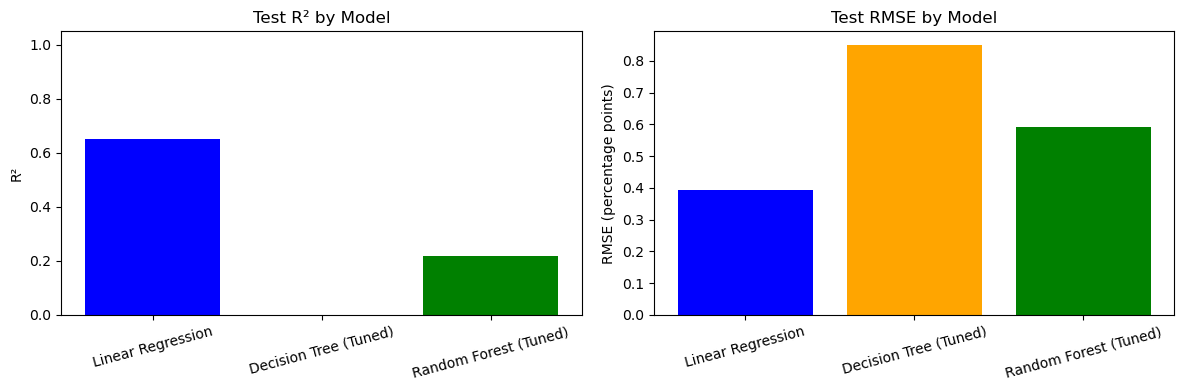

In [116]:
#the bar chart comparing Test R² across models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = results['Model']
axes[0].bar(models, results['Test R²'], color=['blue', 'orange', 'green'])
axes[0].set_title('Test R² by Model')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(models, results['Test RMSE'], color=['blue', 'orange', 'green'])
axes[1].set_title('Test RMSE by Model')
axes[1].set_ylabel('RMSE (percentage points)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

The left chart shows the Test R² score for each model. R² measures how well the model explained the changes in rent growth. A score closer to 1.0 means better predictions. Linear Regression scored the highest at 0.65, Random Forest scored 0.21 and Decision Tree scored near 0 which means it basically could not predict anything useful. The right chart shows the Test RMSE which measures the average size of prediction errors. Lower is better. Linear Regression had the smallest errors at 0.38, Random Forest was in the middle at 0.60, and Decision Tree had the worst errors at 0.85. Both charts point to the same winner. Linear Regression predicted rent growth the most accurately and made the smallest errors on data it had never seen before. This confirms that Linear Regression is the best model for this project.

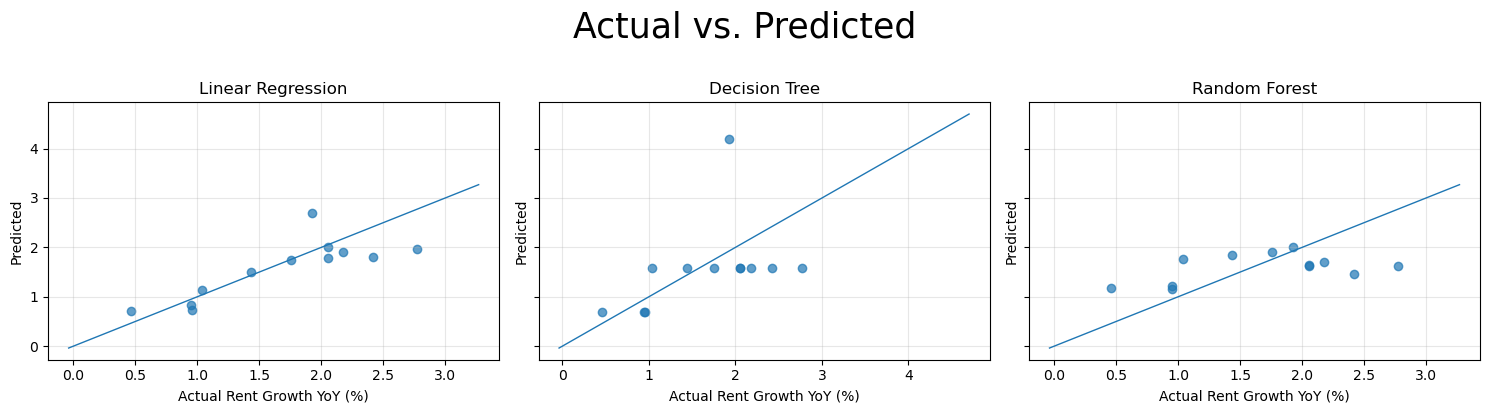

In [109]:
# Actual vs Predicted plot for all three models on the test set
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

preds_list = [m1_preds, m2_preds, m3_preds]
titles = ['Linear Regression', 'Decision Tree', 'Random Forest']

for ax, preds, title in zip(axes, preds_list, titles):
    ax.scatter(y_test, preds, alpha=0.7)
    lims = [min(y_test.min(), preds.min()) - 0.5,
            max(y_test.max(), preds.max()) + 0.5]
    ax.plot(lims, lims, linewidth=1)
    ax.set_xlabel('Actual Rent Growth YoY (%)')
    ax.set_ylabel('Predicted')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs. Predicted', fontsize=25, y=1.02)
plt.tight_layout()
plt.show()

### Final Model Selection

The scatter plots above show how close each model's predictions were to the real values. Each dot is one month. When dots line up along the diagonal line it means the model predicted correctly. When dots are spread far from the line it means the model made bigger errors. Linear Regression shows the dots following the line most closely which means it predicted the best on this test set. The Decision Tree has one dot far off the line which hurt its score. The Random Forest dots are more spread out which means it struggled more with this small test set. I pick Linear Regression as my final model because it predicted closest to the actual values, had the best test scores and is the simplest model which makes it easy to understand and explain. With only 12 test months the simpler model worked better than the more complex ones.

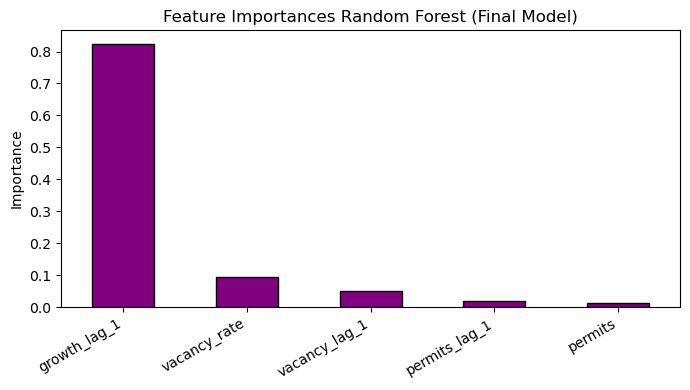

growth_lag_1     0.825071
vacancy_rate     0.094971
vacancy_lag_1    0.049345
permits_lag_1    0.019412
permits          0.011201
dtype: float64


In [99]:
# Feature importances from the final Random Forest model
final_model = rf_grid.best_estimator_
importances = pd.Series(final_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
importances.plot(kind='bar', color='purple', edgecolor='black')
plt.title('Feature Importances Random Forest (Final Model)')
plt.ylabel('Importance')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(importances)

This chart shows which columns the Random Forest used most when making predictions. Last month's rent growth (growth_lag_1) was by far the most important input at 0.83 which matches what I found in EDA where it had a 0.973 correlation with rent growth. Vacancy rate and last month's vacancy rate were the next most useful inputs which makes sense because when fewer apartments are empty landlords can raise rents more. Building permits contributed very little to the model's predictions.

## 8. Conclusion
I built and compared three models to predict year-over-year rent growth for multifamily properties... finish 
make sure to write about standardizarion - linear regression, no need for random tree